vit-tiny 2블록 20만개

In [ ]:
# vit-tiny 2블록 20만개 timm_vit_finetuned_best.pth
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 ViT 모델 파인튜닝 - 후반 2개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 (전체 데이터를 사용)
    df = pd.read_csv(labels_csv_path)
    df = df.head(200000)
    print("CSV preview:")
    print(df.head())

    # train/validation 분할 (클래스 비율 유지)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # vit_tiny_patch16_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 2개 블록만 학습)
    # -----------------------------
    model_name = 'vit_tiny_patch16_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # 전체 Transformer 블록 중, 마지막 2개 블록만 학습시키고 나머지는 동결합니다.
    total_blocks = len(model.blocks)
    num_trainable = 2  # 마지막 2개의 블록만 학습
    for i, block in enumerate(model.blocks):
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # 학습 가능한 파라미터 수 출력
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # -----------------------------
    # 6. 학습 루프 (최고 validation 성능일 때 모델 저장)
    # -----------------------------
    num_epochs = 30
    best_val_acc = 0.0  # 최고 검증 정확도 기록

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 성능일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_path = os.path.join(dataset_dir, "timm_vit_finetuned_best.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(200000)_(2)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)



C:\Users\rkatk\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(


Epoch 1/30 - Validation: 100%|██████████████████████████████████████████████████████| 313/313 [00:43<00:00,  7.18it/s]


Epoch 1/30: Train Loss: 0.5092, Train Acc: 0.7524 | Val Loss: 0.5381, Val Acc: 0.7221
Best model updated at epoch 1 with Val Acc: 0.7221


Epoch 2/30 - Validation: 100%|██████████████████████████████████████████████████████| 313/313 [00:43<00:00,  7.12it/s]


...

Epoch 28/30: Train Loss: 0.4198, Train Acc: 0.8121 | Val Loss: 0.4479, Val Acc: 0.7947


Epoch 29/30 - Validation: 100%|█████████████████████████████████████████████████████| 313/313 [00:44<00:00,  7.02it/s]


Epoch 29/30: Train Loss: 0.4188, Train Acc: 0.8130 | Val Loss: 0.4574, Val Acc: 0.7919


Epoch 30/30 - Validation: 100%|█████████████████████████████████████████████████████| 313/313 [00:44<00:00,  7.08it/s]

Epoch 30/30: Train Loss: 0.4187, Train Acc: 0.8133 | Val Loss: 0.4504, Val Acc: 0.7950
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_vit_tiny_finetuned(200000)_(2)_final.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스 (재사용)
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 검증 데이터셋 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels.csv")

# vit_tiny_patch16_224 모델의 기본 입력 크기에 맞춘 검증용 전처리
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 3. 모델 불러오기 및 준비
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'vit_tiny_patch16_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# 이전에 파인튜닝할 때, 후반 2개 블록만 학습하도록 설정했던 부분을 동일하게 적용합니다.
total_blocks = len(model.blocks)
num_trainable = 2
for i, block in enumerate(model.blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

model = model.to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "timm_vit_finetuned_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 4. 검증 데이터셋으로 예측 및 평가 (accuracy, ROC AUC)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력
        probs = torch.softmax(outputs, dim=1)  # 클래스별 확률
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # 양성 클래스(예: label 1)에 대한 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

# 정확도 계산
accuracy = accuracy_score(all_labels, all_preds)
# ROC AUC 계산 (양성 클래스 확률 사용)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


C:\Users\rkatk\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:45<00:00,  6.82it/s]

Validation Accuracy: 0.7981
Validation ROC AUC: 0.8746


swin-tiny 2개 블록 20만개



In [ ]:
# swin-tiny 2개 블록 20만개 timm_swin_finetuned(200000)_(2)_final_best.pth
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 Swin Transformer 파인튜닝 - 후반 4개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 20만개 데이터 사용
    #df = pd.read_csv(labels_csv_path)
    #df = df.head(200000)
    #print("CSV preview:")
    #print(df.head())

    # train/validation 분할 (클래스 비율 유지)
    #train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    #train_df.to_csv(train_csv, index=False)
    #val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # swin_tiny_patch4_window7_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 4개 블록만 학습)
    # -----------------------------
    model_name = 'swin_tiny_patch4_window7_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # Swin Transformer는 여러 stage(layer)로 구성되며, 각 stage는 여러 블록(blocks)으로 구성됩니다.
    # 전체 블록을 순서대로 리스트에 모은 후, 마지막 일부 블록만 학습하도록 나머지 블록을 동결합니다.
    all_blocks = []
    for layer in model.layers:
        for block in layer.blocks:
            all_blocks.append(block)
    total_blocks = len(all_blocks)
    num_trainable = 2  # 여기서는 마지막 2개의 블록만 학습 (코멘트와 다르게 4개 대신 2개만 학습)
    for i, block in enumerate(all_blocks):
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # 학습 가능한 파라미터 수 출력 (동결되지 않은 파라미터들)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    # 동결되지 않은 파라미터들만 업데이트합니다.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # -----------------------------
    # 6. 학습 루프 (최고 validation 정확도 모델 저장)
    # -----------------------------
    num_epochs = 30
    best_val_acc = 0.0  # 최고 validation 정확도 기록
    best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(200000)_(2)_final_best.pth")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 정확도일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(200000)_(2)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)


Using device: cuda
SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
  

Epoch 1/30 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:32<00:00,  3.37it/s]


Epoch 1/30: Train Loss: 0.4749, Train Acc: 0.7782 | Val Loss: 0.4378, Val Acc: 0.8009
Best model updated at epoch 1 with Val Acc: 0.8009


Epoch 2/30 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:26<00:00,  3.61it/s]


Epoch 2/30: Train Loss: 0.4484, Train Acc: 0.7964 | Val Loss: 0.4309, Val Acc: 0.8085
Best model updated at epoch 2 with Val Acc: 0.8085


...

Epoch 28/30: Train Loss: 0.3471, Train Acc: 0.8514 | Val Loss: 0.4655, Val Acc: 0.8043


Epoch 29/30 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:32<00:00,  3.37it/s]


Epoch 29/30: Train Loss: 0.3413, Train Acc: 0.8552 | Val Loss: 0.4795, Val Acc: 0.8014


Epoch 30/30 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:32<00:00,  3.37it/s]


Epoch 30/30: Train Loss: 0.3335, Train Acc: 0.8582 | Val Loss: 0.5082, Val Acc: 0.7972
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_swin_finetuned(200000)_(2)_final.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 검증 데이터셋 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels.csv")

# 모델의 기본 입력 크기(224×224)에 맞춘 검증 전처리
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 3. 모델 불러오기 및 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'swin_tiny_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# 학습 시 후반 2개 블록만 학습하도록 동결한 것과 동일하게 재구성
all_blocks = []
for layer in model.layers:
    for block in layer.blocks:
        all_blocks.append(block)
total_blocks = len(all_blocks)
num_trainable = 2  # 마지막 2개 블록만 학습
for i, block in enumerate(all_blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

model = model.to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(200000)_(2)_final_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 4. 검증 데이터셋 평가 (Accuracy, ROC AUC)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력
        probs = torch.softmax(outputs, dim=1)  # 클래스별 확률 계산
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # 양성 클래스(예: label 1) 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

# 정확도 계산
accuracy = accuracy_score(all_labels, all_preds)
# ROC AUC 계산 (양성 클래스 확률 사용)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:38<00:00,  3.17it/s]

Validation Accuracy: 0.8137
Validation ROC AUC: 0.8887


In [ ]:
CNN 20만개

In [ ]:
#CNN 20만개 cnn(200000)_final_best.pth
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기를 128*9*9로 수정
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 메인 코드
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 20만개 데이터 사용
    #df = pd.read_csv(labels_csv_path)
    #df = df.head(200000)
    #print("CSV preview:")
    #print(df.head())

    # train/validation 데이터셋 분할 (80:20, 클래스 비율 유지)
    #train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    #train_df.to_csv(train_csv, index=False)
    #val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 5. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # 학습 시 데이터 증강(transformations)
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    # 검증 시 변환: Tensor 변환만 적용
    val_transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 6. 모델, weight 초기화, 손실함수, 옵티마이저 설정
    # -----------------------------
    model = CNNClassifier().to(device)
    model.apply(weight_init)  # He-uniform 초기화 적용
    print(model)

    # 학습 가능한 파라미터 수 출력
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # Loss: Categorical Cross-Entropy (PyTorch의 CrossEntropyLoss는 logits를 입력받음)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # -----------------------------
    # 7. 학습 루프 (최고 validation 정확도 모델 저장)
    # -----------------------------
    num_epochs = 50
    best_val_acc = 0.0
    best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_best.pth")

    for epoch in range(num_epochs):
        # 학습 단계
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 정확도일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 8. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "cnn(200000)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)


Using device: cuda
CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, d

Epoch 1/50 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:22<00:00, 13.94it/s]


Epoch 1/50: Train Loss: 0.6552, Train Acc: 0.6303 | Val Loss: 0.5935, Val Acc: 0.7010
Best model updated at epoch 1 with Val Acc: 0.7010


Epoch 2/50 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:25<00:00, 12.34it/s]


Epoch 2/50: Train Loss: 0.5914, Train Acc: 0.6881 | Val Loss: 0.5526, Val Acc: 0.7242
Best model updated at epoch 2 with Val Acc: 0.7242


...

Epoch 48/50: Train Loss: 0.4694, Train Acc: 0.7872 | Val Loss: 0.4469, Val Acc: 0.7983


Epoch 49/50 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.76it/s]


Epoch 49/50: Train Loss: 0.4692, Train Acc: 0.7870 | Val Loss: 0.4406, Val Acc: 0.8028
Best model updated at epoch 49 with Val Acc: 0.8028


Epoch 50/50 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.66it/s]

Epoch 50/50: Train Loss: 0.4676, Train Acc: 0.7888 | Val Loss: 0.4413, Val Acc: 0.8020
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)


CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.77it/s]


Additional Epoch 1/10: Train Loss: 0.4683, Train Acc: 0.7887 | Val Loss: 0.4428, Val Acc: 0.8011
Best model updated at additional epoch 1 with Val Acc: 0.8011


Additional Epoch 2/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:22<00:00, 13.98it/s]


Additional Epoch 2/10: Train Loss: 0.4680, Train Acc: 0.7885 | Val Loss: 0.4405, Val Acc: 0.8022
Best model updated at additional epoch 2 with Val Acc: 0.8022


...

Additional Epoch 8/10: Train Loss: 0.4649, Train Acc: 0.7903 | Val Loss: 0.4388, Val Acc: 0.8034


Additional Epoch 9/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.90it/s]


Additional Epoch 9/10: Train Loss: 0.4647, Train Acc: 0.7902 | Val Loss: 0.4444, Val Acc: 0.8001


Additional Epoch 10/10 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.82it/s]


Additional Epoch 10/10: Train Loss: 0.4653, Train Acc: 0.7891 | Val Loss: 0.4390, Val Acc: 0.8033
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional2_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional2.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:25<00:00, 12.49it/s]


Additional Epoch 1/10: Train Loss: 0.4634, Train Acc: 0.7915 | Val Loss: 0.4389, Val Acc: 0.8036
Best model updated at additional epoch 1 with Val Acc: 0.8036


Additional Epoch 2/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.76it/s]


Additional Epoch 2/10: Train Loss: 0.4644, Train Acc: 0.7900 | Val Loss: 0.4375, Val Acc: 0.8041
Best model updated at additional epoch 2 with Val Acc: 0.8041


...

Additional Epoch 8/10: Train Loss: 0.4618, Train Acc: 0.7914 | Val Loss: 0.4379, Val Acc: 0.8039


Additional Epoch 9/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.68it/s]


Additional Epoch 9/10: Train Loss: 0.4624, Train Acc: 0.7917 | Val Loss: 0.4375, Val Acc: 0.8050
Best model updated at additional epoch 9 with Val Acc: 0.8050


Additional Epoch 10/10 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:23<00:00, 13.42it/s]

Additional Epoch 10/10: Train Loss: 0.4624, Train Acc: 0.7919 | Val Loss: 0.4367, Val Acc: 0.8047
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional2.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional2.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional3_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional3.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.88it/s]


Additional Epoch 1/10: Train Loss: 0.4615, Train Acc: 0.7929 | Val Loss: 0.4381, Val Acc: 0.8047
Best model updated at additional epoch 1 with Val Acc: 0.8047


Additional Epoch 2/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.67it/s]


Additional Epoch 2/10: Train Loss: 0.4612, Train Acc: 0.7935 | Val Loss: 0.4380, Val Acc: 0.8054
Best model updated at additional epoch 2 with Val Acc: 0.8054


...

Additional Epoch 8/10: Train Loss: 0.4589, Train Acc: 0.7944 | Val Loss: 0.4383, Val Acc: 0.8051


Additional Epoch 9/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.75it/s]


Additional Epoch 9/10: Train Loss: 0.4599, Train Acc: 0.7932 | Val Loss: 0.4359, Val Acc: 0.8056


Additional Epoch 10/10 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.85it/s]


Additional Epoch 10/10: Train Loss: 0.4601, Train Acc: 0.7932 | Val Loss: 0.4359, Val Acc: 0.8057
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional3.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional3.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional4_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional4.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_mode)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.66it/s]


Additional Epoch 1/10: Train Loss: 0.4590, Train Acc: 0.7940 | Val Loss: 0.4370, Val Acc: 0.8051
Best model updated at additional epoch 1 with Val Acc: 0.8051


Additional Epoch 2/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:23<00:00, 13.22it/s]


Additional Epoch 2/10: Train Loss: 0.4594, Train Acc: 0.7938 | Val Loss: 0.4368, Val Acc: 0.8058
Best model updated at additional epoch 2 with Val Acc: 0.8058


...

Additional Epoch 8/10: Train Loss: 0.4574, Train Acc: 0.7943 | Val Loss: 0.4354, Val Acc: 0.8059


Additional Epoch 9/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:20<00:00, 15.25it/s]


Additional Epoch 9/10: Train Loss: 0.4581, Train Acc: 0.7940 | Val Loss: 0.4367, Val Acc: 0.8050


Additional Epoch 10/10 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:20<00:00, 15.22it/s]


Additional Epoch 10/10: Train Loss: 0.4575, Train Acc: 0.7960 | Val Loss: 0.4354, Val Acc: 0.8063
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional4.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional4.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional5_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional5.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:23<00:00, 13.23it/s]


Additional Epoch 1/10: Train Loss: 0.4582, Train Acc: 0.7950 | Val Loss: 0.4353, Val Acc: 0.8052
Best model updated at additional epoch 1 with Val Acc: 0.8052


Additional Epoch 2/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:25<00:00, 12.33it/s]


Additional Epoch 2/10: Train Loss: 0.4564, Train Acc: 0.7963 | Val Loss: 0.4346, Val Acc: 0.8059
Best model updated at additional epoch 2 with Val Acc: 0.8059


...

Additional Epoch 8/10: Train Loss: 0.4557, Train Acc: 0.7958 | Val Loss: 0.4364, Val Acc: 0.8060


Additional Epoch 9/10 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:20<00:00, 14.95it/s]


Additional Epoch 9/10: Train Loss: 0.4558, Train Acc: 0.7960 | Val Loss: 0.4339, Val Acc: 0.8075
Best model updated at additional epoch 9 with Val Acc: 0.8075


Additional Epoch 10/10 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:22<00:00, 13.94it/s]


Additional Epoch 10/10: Train Loss: 0.4557, Train Acc: 0.7960 | Val Loss: 0.4333, Val Acc: 0.8075
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional5.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional5.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 30
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional6_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional6.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

#100번째 +30번째 에포크인거임

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.83it/s]


Additional Epoch 1/30: Train Loss: 0.4560, Train Acc: 0.7953 | Val Loss: 0.4348, Val Acc: 0.8060
Best model updated at additional epoch 1 with Val Acc: 0.8060


Additional Epoch 2/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.81it/s]


Additional Epoch 2/30: Train Loss: 0.4544, Train Acc: 0.7960 | Val Loss: 0.4352, Val Acc: 0.8050


...

Additional Epoch 28/30: Train Loss: 0.4520, Train Acc: 0.7984 | Val Loss: 0.4329, Val Acc: 0.8071


Additional Epoch 29/30 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:20<00:00, 15.05it/s]


Additional Epoch 29/30: Train Loss: 0.4524, Train Acc: 0.7974 | Val Loss: 0.4324, Val Acc: 0.8069


Additional Epoch 30/30 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:20<00:00, 14.93it/s]

Additional Epoch 30/30: Train Loss: 0.4515, Train Acc: 0.7986 | Val Loss: 0.4329, Val Acc: 0.8064
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional6.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional6.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 70
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional7_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional7.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/70 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:22<00:00, 13.63it/s]


Additional Epoch 1/70: Train Loss: 0.4521, Train Acc: 0.7978 | Val Loss: 0.4314, Val Acc: 0.8074
Best model updated at additional epoch 1 with Val Acc: 0.8074


Additional Epoch 2/70 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.85it/s]


Additional Epoch 2/70: Train Loss: 0.4520, Train Acc: 0.7984 | Val Loss: 0.4318, Val Acc: 0.8075
Best model updated at additional epoch 2 with Val Acc: 0.8075


...

Additional Epoch 68/70: Train Loss: 0.4452, Train Acc: 0.8017 | Val Loss: 0.4300, Val Acc: 0.8094


Additional Epoch 69/70 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.63it/s]


Additional Epoch 69/70: Train Loss: 0.4449, Train Acc: 0.8012 | Val Loss: 0.4298, Val Acc: 0.8089


Additional Epoch 70/70 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.62it/s]

Additional Epoch 70/70: Train Loss: 0.4462, Train Acc: 0.8020 | Val Loss: 0.4309, Val Acc: 0.8095
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional7.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 여기서는 이전 학습 시 사용했던 train_labels.csv, val_labels.csv 파일을 그대로 사용합니다.
train_csv = os.path.join(dataset_dir, "train_labels.csv")
val_csv = os.path.join(dataset_dir, "val_labels.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델, 초기화, 손실함수, 옵티마이저 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional7.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final best model from:", final_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 동안 추가 학습, validation 정확도 최고일 때 모델 저장)
# -----------------------------
additional_epochs = 100
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional8_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional8.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/100 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.78it/s]


Additional Epoch 1/100: Train Loss: 0.4444, Train Acc: 0.8022 | Val Loss: 0.4309, Val Acc: 0.8084
Best model updated at additional epoch 1 with Val Acc: 0.8084


Additional Epoch 2/100 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:24<00:00, 12.77it/s]


Additional Epoch 2/100: Train Loss: 0.4460, Train Acc: 0.8010 | Val Loss: 0.4297, Val Acc: 0.8093
Best model updated at additional epoch 2 with Val Acc: 0.8093


...

Additional Epoch 98/100: Train Loss: 0.4385, Train Acc: 0.8056 | Val Loss: 0.4297, Val Acc: 0.8095


Additional Epoch 99/100 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.62it/s]


Additional Epoch 99/100: Train Loss: 0.4390, Train Acc: 0.8052 | Val Loss: 0.4283, Val Acc: 0.8103


Additional Epoch 100/100 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.59it/s]


Additional Epoch 100/100: Train Loss: 0.4383, Train Acc: 0.8066 | Val Loss: 0.4295, Val Acc: 0.8104
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(200000)_final_additional8.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의 (학습 시 사용한 모델 구조)
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기 128*9*9
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. 검증 데이터셋 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels.csv")

# 평가 시에는 학습 시 사용한 검증 전처리(transform)와 동일하게 설정합니다.
# 여기서는 단순히 ToTensor()만 적용한 것으로 가정합니다.
val_transform = transforms.Compose([
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 4. 모델 불러오기 및 평가 준비
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "cnn(200000)_final_additional8_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 5. 검증 데이터셋 평가 (Accuracy, ROC AUC)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # 출력: (batch_size, 2)
        probs = torch.softmax(outputs, dim=1)  # 각 클래스의 확률
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해 양성 클래스 (label 1)의 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.55it/s]

Validation Accuracy: 0.8110
Validation ROC AUC: 0.8845


cnn 2만개

In [ ]:
# cnn 2만개 cnn(20000)_final_best.pth
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기를 128*9*9로 수정
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 메인 코드
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 20만개 데이터 사용
    df = pd.read_csv(labels_csv_path)
    df = df.head(20000)
    print("CSV preview:")
    print(df.head())

    # train/validation 데이터셋 분할 (80:20, 클래스 비율 유지)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
    val_csv = os.path.join(dataset_dir, "val_labels_2.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 5. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # 학습 시 데이터 증강(transformations)
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    # 검증 시 변환: Tensor 변환만 적용
    val_transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 6. 모델, weight 초기화, 손실함수, 옵티마이저 설정
    # -----------------------------
    model = CNNClassifier().to(device)
    model.apply(weight_init)  # He-uniform 초기화 적용
    print(model)

    # 학습 가능한 파라미터 수 출력
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # Loss: Categorical Cross-Entropy (PyTorch의 CrossEntropyLoss는 logits를 입력받음)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # -----------------------------
    # 7. 학습 루프 (최고 validation 정확도 모델 저장)
    # -----------------------------
    num_epochs = 30
    best_val_acc = 0.0
    best_model_path = os.path.join(dataset_dir, "cnn(20000)_final_best.pth")

    for epoch in range(num_epochs):
        # 학습 단계
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 정확도일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 8. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "cnn(20000)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)

Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, mom

Epoch 1/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 10.74it/s]


Epoch 1/30: Train Loss: 0.8091, Train Acc: 0.5609 | Val Loss: 0.6645, Val Acc: 0.6172
Best model updated at epoch 1 with Val Acc: 0.6172


Epoch 2/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 10.67it/s]


Epoch 2/30: Train Loss: 0.6617, Train Acc: 0.6078 | Val Loss: 0.6417, Val Acc: 0.6512
Best model updated at epoch 2 with Val Acc: 0.6512


...

Epoch 28/30: Train Loss: 0.5443, Train Acc: 0.7294 | Val Loss: 0.5416, Val Acc: 0.7315


Epoch 29/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:01<00:00, 16.44it/s]


Epoch 29/30: Train Loss: 0.5422, Train Acc: 0.7295 | Val Loss: 0.5290, Val Acc: 0.7348


Epoch 30/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:01<00:00, 16.53it/s]

Epoch 30/30: Train Loss: 0.5403, Train Acc: 0.7294 | Val Loss: 0.5350, Val Acc: 0.7328
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(20000)_final.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)  # 예: 72×72 -> 36×36
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 36×36 -> 18×18
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)  # 18×18 -> 9×9
        )
        # Fully Connected Layers: 입력 크기를 128*9*9로 수정
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 이전 학습 시 사용한 CSV 파일들
train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 5. 모델 구성 및 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)
model.apply(weight_init)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# 6. 기존 최종 모델 불러오기
# -----------------------------
# 이전에 학습된 최종 모델의 best checkpoint 불러오기
final_best_model_path = os.path.join(dataset_dir, "cnn(20000)_final.pth")
model.load_state_dict(torch.load(final_best_model_path, map_location=device))
print("Loaded final best model from:", final_best_model_path)

# -----------------------------
# 7. 추가 학습 (30 에폭 추가) 및 최고 validation 정확도 모델 저장
# -----------------------------
additional_epochs = 200
best_val_acc = 0.0
best_model_path = os.path.join(dataset_dir, "cnn(20000)_fina_additional_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    torch.cuda.empty_cache()
    gc.collect()

# -----------------------------
# 8. 추가 학습 후 최종 모델 저장
# -----------------------------
new_final_model_path = os.path.join(dataset_dir, "cnn(20000)_fina_additional.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

Additional Epoch 1/200 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 13.95it/s]


Additional Epoch 1/200: Train Loss: 0.5411, Train Acc: 0.7319 | Val Loss: 0.5287, Val Acc: 0.7343
Best model updated at additional epoch 1 with Val Acc: 0.7343


Additional Epoch 2/200 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 13.91it/s]


Additional Epoch 2/200: Train Loss: 0.5399, Train Acc: 0.7333 | Val Loss: 0.5341, Val Acc: 0.7335


...

Additional Epoch 198/200: Train Loss: 0.4377, Train Acc: 0.7968 | Val Loss: 0.4955, Val Acc: 0.7712


Additional Epoch 199/200 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:01<00:00, 16.69it/s]


Additional Epoch 199/200: Train Loss: 0.4414, Train Acc: 0.8017 | Val Loss: 0.4988, Val Acc: 0.7672


Additional Epoch 200/200 - Validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:01<00:00, 16.74it/s]


Additional Epoch 200/200: Train Loss: 0.4408, Train Acc: 0.8034 | Val Loss: 0.4954, Val Acc: 0.7682
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\cnn(20000)_fina_additional.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의 (학습 시 사용한 구조)
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),
            nn.MaxPool2d(2)
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.MaxPool2d(2)
        )
        # Fully Connected Layers: 입력 크기를 128*9*9로 수정
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 9 * 9, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# -----------------------------
# 3. 검증 데이터셋 및 DataLoader 구성 (val_labels2.csv 사용)
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
# 이번에는 "val_labels2.csv" 파일 사용
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")

# 검증용 전처리 (학습 시 사용한 전처리와 동일하게 입력 크기를 맞춰주면 됩니다)
val_transform = transforms.Compose([
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 4. 모델 불러오기 및 평가 준비
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "cnn(20000)_fina_additional.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 5. 검증 데이터셋 평가 (Accuracy, ROC AUC 계산)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력 (배치, 2)
        probs = torch.softmax(outputs, dim=1)  # 각 클래스에 대한 확률
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해 양성 클래스 (label 1)의 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 16.00it/s]

Validation Accuracy: 0.7682
Validation ROC AUC: 0.8505


In [ ]:
swin-tiny 4블록 2만개

In [ ]:
# swin-tiny 4블록 2만개 timm_swin_finetuned(20000)_(4)_final_best.pth
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 Swin Transformer 파인튜닝 - 후반 4개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 (상위 2만개 데이터 사용)
    #df = pd.read_csv(labels_csv_path)
    #df = df.head(20000)
    #print("CSV preview:")
    #print(df.head())

    # train/validation 분할 (클래스 비율 유지)
    #train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
    val_csv = os.path.join(dataset_dir, "val_labels_2.csv")
    #train_df.to_csv(train_csv, index=False)
    #val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # swin_tiny_patch4_window7_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        #transforms.RandomHorizontalFlip(),  # 데이터 증강 옵션 (필요 시 사용)
        #transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 4개 블록만 학습)
    # -----------------------------
    # 'swin_tiny_patch4_window7_224' 모델을 사전 학습된 가중치로 불러오고,
    # 분류 헤드를 우리의 클래스 수(여기서는 2)로 맞춥니다.
    model_name = 'swin_tiny_patch4_window7_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # Swin Transformer는 여러 stage(layer)로 구성되며, 각 stage는 여러 블록(blocks)으로 구성됩니다.
    # 전체 블록을 순서대로 리스트에 모은 후, 마지막 4개 블록만 학습하도록 나머지 블록을 동결합니다.
    all_blocks = []
    for layer in model.layers:
        for block in layer.blocks:
            all_blocks.append(block)
    total_blocks = len(all_blocks)
    num_trainable = 4  # 마지막 4개의 블록만 학습
    for i, block in enumerate(all_blocks):
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # 학습 가능한 파라미터 수 출력 (동결되지 않은 파라미터들)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    # 동결되지 않은 파라미터들만 업데이트합니다.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # -----------------------------
    # 6. 학습 루프 (최고 validation 정확도 모델 저장)
    # -----------------------------
    num_epochs = 30
    best_val_acc = 0.0
    best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(4)_final_best.pth")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 정확도일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(4)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)


Using device: cuda
SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
  

Epoch 1/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.73it/s]


Epoch 1/30: Train Loss: 0.5343, Train Acc: 0.7319 | Val Loss: 0.4811, Val Acc: 0.7765
Best model updated at epoch 1 with Val Acc: 0.7765


Epoch 2/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.70it/s]


Epoch 2/30: Train Loss: 0.4764, Train Acc: 0.7772 | Val Loss: 0.4805, Val Acc: 0.7740


...

Epoch 28/30: Train Loss: 0.2314, Train Acc: 0.9046 | Val Loss: 0.6872, Val Acc: 0.7670


Epoch 29/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.40it/s]


Epoch 29/30: Train Loss: 0.2152, Train Acc: 0.9142 | Val Loss: 0.7185, Val Acc: 0.7722


Epoch 30/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.72it/s]

Epoch 30/30: Train Loss: 0.2082, Train Acc: 0.9171 | Val Loss: 0.7549, Val Acc: 0.7742
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_swin_finetuned(20000)_(4)_final.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 검증 데이터셋 및 DataLoader 구성 ("val_labels_2.csv" 사용)
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")

# 입력 크기를 224×224로 맞추고 Tensor로 변환
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 3. 모델 불러오기 및 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'swin_tiny_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# Swin Transformer는 여러 stage로 구성되며, 각 stage는 여러 블록(blocks)로 구성됩니다.
# 여기서는 마지막 4개의 블록만 학습한 것으로 학습 시와 동일하게 동결합니다.
all_blocks = []
for layer in model.layers:
    for block in layer.blocks:
        all_blocks.append(block)
total_blocks = len(all_blocks)
num_trainable = 4
for i, block in enumerate(all_blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

model = model.to(device)

# 저장된 best 모델 가중치 불러오기
best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(4)_final_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 4. 검증 데이터셋 평가 (Accuracy, ROC AUC 계산)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력
        probs = torch.softmax(outputs, dim=1)  # 클래스별 확률 계산
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해 양성 클래스(예: label 1)의 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.87it/s]

Validation Accuracy: 0.7947
Validation ROC AUC: 0.8738


 vit-tiny 4블록 2만개

In [ ]:
# vit-tiny 4블록 2만개 timm_vit_tiny_finetuned(20000)_(4)_final_best.pth
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 ViT 모델 파인튜닝 - 후반 2개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 (전체 데이터를 사용)
    #df = pd.read_csv(labels_csv_path)
    #df = df.head(20000)
    #print("CSV preview:")
    #print(df.head())

    # train/validation 분할 (클래스 비율 유지)
    #train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
    val_csv = os.path.join(dataset_dir, "val_labels_2.csv")
    #train_df.to_csv(train_csv, index=False)
    #val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # vit_tiny_patch16_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 2개 블록만 학습)
    # -----------------------------
    model_name = 'vit_tiny_patch16_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # 전체 Transformer 블록 중, 마지막 2개 블록만 학습시키고 나머지는 동결합니다.
    total_blocks = len(model.blocks)
    num_trainable = 4  # 마지막 2개의 블록만 학습
    for i, block in enumerate(model.blocks):
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # 학습 가능한 파라미터 수 출력
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # -----------------------------
    # 6. 학습 루프 (최고 validation 성능일 때 모델 저장)
    # -----------------------------
    num_epochs = 30
    best_val_acc = 0.0  # 최고 검증 정확도 기록

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 성능일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final_best.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)

Using device: cuda
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        

Epoch 1/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:05<00:00,  6.35it/s]


Epoch 1/30: Train Loss: 0.5600, Train Acc: 0.7109 | Val Loss: 0.5962, Val Acc: 0.6688
Best model updated at epoch 1 with Val Acc: 0.6688


Epoch 2/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:05<00:00,  6.28it/s]


Epoch 2/30: Train Loss: 0.5217, Train Acc: 0.7444 | Val Loss: 0.6144, Val Acc: 0.6605


...

Epoch 28/30: Train Loss: 0.3740, Train Acc: 0.8373 | Val Loss: 0.5430, Val Acc: 0.7532


Epoch 29/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.37it/s]


Epoch 29/30: Train Loss: 0.3744, Train Acc: 0.8350 | Val Loss: 0.5260, Val Acc: 0.7630


Epoch 30/30 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.29it/s]

Epoch 30/30: Train Loss: 0.3624, Train Acc: 0.8403 | Val Loss: 0.5350, Val Acc: 0.7568
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_vit_tiny_finetuned(20000)_(4)_final.pth


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 데이터 및 DataLoader 구성
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# -----------------------------
# 3. 모델 구성 및 동결 설정 (이전 학습 시 사용한 설정과 동일)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'vit_tiny_patch16_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# 저장된 모델은 후반 4개 블록만 학습하도록 설정되었으므로 동일하게 동결
total_blocks = len(model.blocks)
num_trainable = 4  # 마지막 4개 블록만 학습
for i, block in enumerate(model.blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

model = model.to(device)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# -----------------------------
# 4. 기존 최종 모델 불러오기
# -----------------------------
final_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final.pth")
model.load_state_dict(torch.load(final_model_path, map_location=device))
print("Loaded final model from:", final_model_path)

# -----------------------------
# 5. 추가 학습 (30 에폭) + best 모델 저장
# -----------------------------
additional_epochs = 30
best_val_acc = 0.0  # 추가 학습 동안의 최고 validation 정확도
best_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final_additional_best.pth")

for epoch in range(additional_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects.double() / total_train

    # 검증 단계
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    print(f"Additional Epoch {epoch+1}/{additional_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at additional epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # 에폭 종료 후 메모리 정리
    torch.cuda.empty_cache()
    gc.collect()

# 추가 학습 후 마지막 모델 저장
new_final_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final_additional.pth")
torch.save(model.state_dict(), new_final_model_path)
print("Additional training complete. New final model saved at:", new_final_model_path)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


Additional Epoch 1/30 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.26it/s]


Additional Epoch 1/30: Train Loss: 0.3540, Train Acc: 0.8450 | Val Loss: 0.5294, Val Acc: 0.7585
Best model updated at additional epoch 1 with Val Acc: 0.7585


Additional Epoch 2/30 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  6.42it/s]


Additional Epoch 2/30: Train Loss: 0.3542, Train Acc: 0.8436 | Val Loss: 0.5194, Val Acc: 0.7585


...

Additional Epoch 28/30: Train Loss: 0.1987, Train Acc: 0.9193 | Val Loss: 0.7712, Val Acc: 0.7365


Additional Epoch 29/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.41it/s]


Additional Epoch 29/30: Train Loss: 0.1957, Train Acc: 0.9193 | Val Loss: 0.7576, Val Acc: 0.7330


Additional Epoch 30/30 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.22it/s]


Additional Epoch 30/30: Train Loss: 0.1886, Train Acc: 0.9216 | Val Loss: 0.7833, Val Acc: 0.7428
Additional training complete. New final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_vit_tiny_finetuned(20000)_(4)_final_additional.pth


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 검증 데이터셋 및 DataLoader 구성
# -----------------------------
# 여기서는 학습 시 사용한 val_labels.csv를 사용합니다.
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")

# vit_tiny_patch16_224 모델의 기본 입력 크기(224×224)에 맞춰 전처리
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 3. 모델 불러오기 및 구성
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'vit_tiny_patch16_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# 학습 시 후반 2개 블록만 학습하도록 설정한 것과 동일하게 동결합니다.
total_blocks = len(model.blocks)
num_trainable = 4  # 여기서는 학습 시 코드에서 num_trainable을 4로 설정했습니다.
for i, block in enumerate(model.blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

model = model.to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "timm_vit_tiny_finetuned(20000)_(4)_final_additional_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# -----------------------------
# 4. 검증 데이터셋 평가 (Accuracy, ROC AUC)
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력
        probs = torch.softmax(outputs, dim=1)  # 각 클래스 확률 계산
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해 양성 클래스 (label 1)의 확률 저장
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  6.68it/s]

Validation Accuracy: 0.7585
Validation ROC AUC: 0.8299


In [ ]:
swin-tiny 2블록 2만개

In [ ]:
# swin-tiny 2블록 2만개 timm_swin_finetuned(20000)_(2)_final_best.pth
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 Swin Transformer 파인튜닝 - 후반 4개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 (상위 2만개 데이터 사용)
    #df = pd.read_csv(labels_csv_path)
    #df = df.head(20000)
    #print("CSV preview:")
    #print(df.head())

    # train/validation 분할 (클래스 비율 유지)
    #train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels_2.csv")
    val_csv = os.path.join(dataset_dir, "val_labels_2.csv")
    #train_df.to_csv(train_csv, index=False)
    #val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # swin_tiny_patch4_window7_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        #transforms.RandomHorizontalFlip(),  # 데이터 증강 옵션 (필요 시 사용)
        #transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 4개 블록만 학습)
    # -----------------------------
    # 'swin_tiny_patch4_window7_224' 모델을 사전 학습된 가중치로 불러오고,
    # 분류 헤드를 우리의 클래스 수(여기서는 2)로 맞춥니다.
    model_name = 'swin_tiny_patch4_window7_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # Swin Transformer는 여러 stage(layer)로 구성되며, 각 stage는 여러 블록(blocks)으로 구성됩니다.
    # 전체 블록을 순서대로 리스트에 모은 후, 마지막 4개 블록만 학습하도록 나머지 블록을 동결합니다.
    all_blocks = []
    for layer in model.layers:
        for block in layer.blocks:
            all_blocks.append(block)
    total_blocks = len(all_blocks)
    num_trainable = 2  # 마지막 2개의 블록만 학습
    for i, block in enumerate(all_blocks):
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # 학습 가능한 파라미터 수 출력 (동결되지 않은 파라미터들)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    # 동결되지 않은 파라미터들만 업데이트합니다.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # -----------------------------
    # 6. 학습 루프 (최고 validation 정확도 모델 저장)
    # -----------------------------
    num_epochs = 50
    best_val_acc = 0.0
    best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(2)_final_best.pth")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 최고 validation 정확도일 때 모델 저장
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장 (마지막 에폭의 모델 저장)
    # -----------------------------
    final_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(2)_final.pth")
    torch.save(model.state_dict(), final_model_path)
    print("Training complete. Final model saved at:", final_model_path)

Using device: cuda
SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
  

Epoch 1/50 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.82it/s]


Epoch 1/50: Train Loss: 0.5280, Train Acc: 0.7381 | Val Loss: 0.5107, Val Acc: 0.7578
Best model updated at epoch 1 with Val Acc: 0.7578


Epoch 2/50 - Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.62it/s]


Epoch 2/50: Train Loss: 0.4896, Train Acc: 0.7672 | Val Loss: 0.4832, Val Acc: 0.7695
Best model updated at epoch 2 with Val Acc: 0.7695


...

Epoch 48/50: Train Loss: 0.1669, Train Acc: 0.9309 | Val Loss: 0.9103, Val Acc: 0.7702


Epoch 49/50 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.81it/s]


Epoch 49/50: Train Loss: 0.1560, Train Acc: 0.9386 | Val Loss: 0.9516, Val Acc: 0.7670


Epoch 50/50 - Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.83it/s]

Epoch 50/50: Train Loss: 0.1492, Train Acc: 0.9401 | Val Loss: 1.0112, Val Acc: 0.7670
Training complete. Final model saved at: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_swin_finetuned(20000)_(2)_final.pth


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score
import timm

# -----------------------------
# 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 검증 데이터셋 및 DataLoader 구성 ("val_labels_2.csv" 사용)
# -----------------------------
dataset_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
val_csv = os.path.join(dataset_dir, "val_labels_2.csv")
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# -----------------------------
# 모델 구성 및 불러오기
# -----------------------------
# Swin-Tiny 모델 생성 (분류 head: 2)
model_name = 'swin_tiny_patch4_window7_224'
model = timm.create_model(model_name, pretrained=True, num_classes=2)

# 학습 시 사용한 것과 동일하게, 전체 Transformer 블록 중 마지막 2개 블록만 학습하도록 나머지 블록 동결
all_blocks = []
for layer in model.layers:
    for block in layer.blocks:
        all_blocks.append(block)
total_blocks = len(all_blocks)
num_trainable = 2  # 마지막 2개 블록만 학습
for i, block in enumerate(all_blocks):
    if i < total_blocks - num_trainable:
        for param in block.parameters():
            param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 저장된 best 모델 불러오기
best_model_path = os.path.join(dataset_dir, "timm_swin_finetuned(20000)_(2)_final_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Loaded best model from:", best_model_path)

# -----------------------------
# 평가: Accuracy 및 ROC AUC 계산
# -----------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # (batch_size, 2)
        probs = nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해 양성 클래스(예: label 1)의 확률 사용
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")



Loaded best model from: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\timm_swin_finetuned(20000)_(2)_final_best.pth


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.50it/s]

Validation Accuracy: 0.8027
Validation ROC AUC: 0.8708


custom swin(no moco)

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import time  # 시간 측정을 위한 모듈

####################################
# Helper functions: window partitioning/reverse
####################################
def window_partition(x, window_size):
    """
    x: (B, H, W, C)
    window_size: int
    return: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous()  # (B, num_win_h, num_win_w, window_size, window_size, C)
    windows = windows.view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    windows: (num_windows*B, window_size, window_size, C)
    return: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(B, H, W, -1)
    return x

####################################
# Patch Embedding
####################################
class PatchEmbed(nn.Module):
    """
    72x72 이미지 -> patch_size=2 -> 36x36 패치 -> 임베딩 dim=64
    """
    def __init__(self, img_size=72, patch_size=2, in_chans=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)

    def forward(self, x):
        # x: (B, 3, 72, 72)
        x = self.proj(x)  # (B, 64, 36, 36)
        x = x.flatten(2).transpose(1,2)  # (B, 36*36, 64)
        return x

####################################
# Window Attention
####################################
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads)
        )
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:,:,0] += window_size - 1
        relative_coords[:,:,1] += window_size - 1
        relative_coords[:,:,0] *= 2 * window_size - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

    def forward(self, x, mask=None):
        """
        x: (num_windows*B, window_size*window_size, C)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B_, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) / (q.shape[-1] ** 0.5)

        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size * self.window_size, self.window_size * self.window_size, -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).unsqueeze(0)
        attn = attn + relative_position_bias

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = nn.functional.softmax(attn, dim=-1)
        else:
            attn = nn.functional.softmax(attn, dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj(out)
        return out

####################################
# Swin Transformer Block
####################################
class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )

        if shift_size > 0:
            H, W = input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -window_size),
                        slice(-window_size, -shift_size),
                        slice(-shift_size, None))
            w_slices = (slice(0, -window_size),
                        slice(-window_size, -shift_size),
                        slice(-shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, window_size)
            mask_windows = mask_windows.view(-1, window_size * window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        B, L, C = x.shape
        H, W = self.input_resolution
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1,2))
        else:
            shifted_x = x

        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows, mask=self.attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1,2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

####################################
# Patch Merging
####################################
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature size mismatch"
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], dim=-1)
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        return x

####################################
# Swin Stage
####################################
class SwinTransformerStage(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size=3, mlp_ratio=4.0):
        super().__init__()
        self.blocks = nn.ModuleList()
        for i in range(depth):
            shift_size = window_size // 2 if (i % 2 == 1) else 0
            block = SwinTransformerBlock(dim, input_resolution, num_heads, window_size, shift_size, mlp_ratio)
            self.blocks.append(block)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return x

####################################
# 최종 Swin 모델
####################################
class CustomSwinTransformer(nn.Module):
    """
    72x72 이미지 -> PatchEmbed (36x36 패치) -> Stage1 -> PatchMerging (18x18) -> Stage2 -> PatchMerging (9x9) -> Stage3 -> Global Pooling -> Head
    """
    def __init__(self, img_size=72, patch_size=2, in_chans=3,
                 stage_blocks=[2,2,4], stage_dims=[64,128,256],
                 stage_heads=[2,4,8], window_size=3, num_classes=2):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, stage_dims[0])
        resolution = (img_size // patch_size, img_size // patch_size)  # (36, 36)
        self.stage1 = SwinTransformerStage(stage_dims[0], resolution, stage_blocks[0], stage_heads[0], window_size)
        self.patch_merging1 = PatchMerging(resolution, stage_dims[0])
        resolution_stage2 = (resolution[0]//2, resolution[1]//2)  # (18, 18)
        self.stage2 = SwinTransformerStage(stage_dims[1], resolution_stage2, stage_blocks[1], stage_heads[1], window_size)
        self.patch_merging2 = PatchMerging(resolution_stage2, stage_dims[1])
        resolution_stage3 = (resolution_stage2[0]//2, resolution_stage2[1]//2)  # (9, 9)
        self.stage3 = SwinTransformerStage(stage_dims[2], resolution_stage3, stage_blocks[2], stage_heads[2], window_size)
        self.norm = nn.LayerNorm(stage_dims[2])
        self.head = nn.Linear(stage_dims[2], num_classes)

    def forward_features(self, x):
        x = self.patch_embed(x)
        x = self.stage1(x)
        x = self.patch_merging1(x)
        x = self.stage2(x)
        x = self.patch_merging2(x)
        x = self.stage3(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

print("===== Swin Transformer 모델 정의 완료 =====")

####################################
# 데이터 준비
####################################
img_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
csv_file = os.path.join(img_dir, "labels.csv")

train_transform = transforms.Compose([
    transforms.ToTensor()
])

# MyDataset: 앞 20만 개만 사용
class MyDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None, max_samples=200000):
        self.img_dir = img_dir
        df = pd.read_csv(csv_file)
        df = df.iloc[:max_samples].reset_index(drop=True)
        self.labels_df = df
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

dataset = MyDataset(img_dir, csv_file, transform=train_transform, max_samples=200000)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset = Subset(dataset, range(0, train_size))
val_dataset = Subset(dataset, range(train_size, len(dataset)))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

####################################
# 모델 초기화
####################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomSwinTransformer(
    img_size=72,
    patch_size=2,
    in_chans=3,
    stage_blocks=[2,2,4],
    stage_dims=[64,128,256],
    stage_heads=[2,4,8],
    window_size=3,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

####################################
# 모델 파라미터 수 출력
####################################
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params}")

####################################
# 학습 루프: 최대 validation 정확도일 때 모델 저장 (추가학습)
####################################
num_epochs = 20
best_val_acc = 0.0
best_model_path = os.path.join(img_dir, "swin_transformer_72x72_200k_final_best.pth")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} | Time: {time.strftime('%M:%S', time.gmtime(epoch_time))}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at epoch {epoch+1} with Val Acc: {best_val_acc:.4f}")

print("학습 완료!")
torch.save(model.state_dict(), "swin_transformer_72x72_200k_final.pth")
print("최종 모델 파라미터가 저장되었습니다.")


===== Swin Transformer 모델 정의 완료 =====
Total model parameters: 3823886


Epoch [1/20] Train Loss: 0.5716 Train Acc: 0.6891 | Val Loss: 0.4880 Val Acc: 0.7685 | Time: 03:48
Best model updated at epoch 1 with Val Acc: 0.7685


Epoch [2/20] Train Loss: 0.4979 Train Acc: 0.7630 | Val Loss: 0.4783 Val Acc: 0.7760 | Time: 04:04
Best model updated at epoch 2 with Val Acc: 0.7760


Epoch [3/20] Train Loss: 0.4882 Train Acc: 0.7697 | Val Loss: 0.4745 Val Acc: 0.7805 | Time: 03:54
Best model updated at epoch 3 with Val Acc: 0.7805


Epoch [4/20] Train Loss: 0.4815 Train Acc: 0.7752 | Val Loss: 0.4740 Val Acc: 0.7800 | Time: 03:52


...

Epoch [16/20] Train Loss: 0.4453 Train Acc: 0.7978 | Val Loss: 0.4536 Val Acc: 0.7939 | Time: 03:52


Epoch [17/20] Train Loss: 0.4427 Train Acc: 0.7994 | Val Loss: 0.4524 Val Acc: 0.7944 | Time: 03:52


Epoch [18/20] Train Loss: 0.4401 Train Acc: 0.8000 | Val Loss: 0.4556 Val Acc: 0.7936 | Time: 03:52


Epoch [19/20] Train Loss: 0.4371 Train Acc: 0.8031 | Val Loss: 0.4531 Val Acc: 0.7938 | Time: 03:52


Epoch [20/20] Train Loss: 0.4344 Train Acc: 0.8044 | Val Loss: 0.4555 Val Acc: 0.7912 | Time: 03:52
학습 완료!
최종 모델 파라미터가 저장되었습니다.


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score

# CustomSwinTransformer와 MyDataset 클래스가 이미 정의되어 있다고 가정합니다.
# (아래는 이전에 사용한 MyDataset 클래스 예시입니다.)
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, csv_file, transform=None, max_samples=200000):
        self.img_dir = img_dir
        df = pd.read_csv(csv_file)
        df = df.iloc[:max_samples].reset_index(drop=True)
        self.labels_df = df
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# 데이터 준비
img_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
csv_file = os.path.join(img_dir, "labels.csv")
# 평가 시에는 단순히 ToTensor()만 적용 (학습 시와 동일하게 설정)
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = MyDataset(img_dir, csv_file, transform=transform, max_samples=200000)
# train/validation 분할 (80:20) -- 여기서는 validation subset만 사용
train_size = int(0.8 * len(dataset))
val_dataset = Subset(dataset, range(train_size, len(dataset)))
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

# 모델 불러오기: CustomSwinTransformer 인스턴스 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomSwinTransformer(
    img_size=72,
    patch_size=2,
    in_chans=3,
    stage_blocks=[2,2,4],
    stage_dims=[64,128,256],
    stage_heads=[2,4,8],
    window_size=3,
    num_classes=2
).to(device)

# 저장된 best 모델 가중치 로드
best_model_path = os.path.join(img_dir, "swin_transformer_72x72_200k_final_best.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Loaded best model from:", best_model_path)

# 평가: Accuracy와 ROC AUC 계산
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)  # logits 출력
        probs = nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        # ROC AUC 계산을 위해, 양성 클래스(예: label 1)의 확률 사용
        all_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")


Loaded best model from: C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)\swin_transformer_72x72_200k_final_best.pth


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:26<00:00, 23.70it/s]

Validation Accuracy: 0.7948
Validation ROC AUC: 0.8692


custom swin(with moco)

===== Swin Transformer 모델 정의 완료 =====
모코(MoCo) 모델 및 유틸리티 정의 완료.
사전학습된 가중치가 성공적으로 로드되었습니다.
총 모델 파라미터 수: 3823886


Epoch [1/20] Train Loss: 0.4630, Train Acc: 0.7867 | Val Loss: 0.4428, Val Acc: 0.8014 | Time: 04:03
새로운 최고 검증 정확도 0.8014 달성! 모델 저장: finetuned_swin72_best.pth


Epoch [2/20] Train Loss: 0.4463, Train Acc: 0.7973 | Val Loss: 0.4351, Val Acc: 0.8041 | Time: 04:03
새로운 최고 검증 정확도 0.8041 달성! 모델 저장: finetuned_swin72_best.pth


Epoch [3/20] Train Loss: 0.4419, Train Acc: 0.8007 | Val Loss: 0.4362, Val Acc: 0.8055 | Time: 04:03
새로운 최고 검증 정확도 0.8055 달성! 모델 저장: finetuned_swin72_best.pth


Epoch [4/20] Train Loss: 0.4392, Train Acc: 0.8026 | Val Loss: 0.4339, Val Acc: 0.8058 | Time: 04:03
새로운 최고 검증 정확도 0.8058 달성! 모델 저장: finetuned_swin72_best.pth


...

Epoch [16/20] Train Loss: 0.4217, Train Acc: 0.8135 | Val Loss: 0.4376, Val Acc: 0.8020 | Time: 04:04


Epoch [17/20] Train Loss: 0.4203, Train Acc: 0.8145 | Val Loss: 0.4269, Val Acc: 0.8116 | Time: 04:04
새로운 최고 검증 정확도 0.8116 달성! 모델 저장: finetuned_swin72_best.pth


Epoch [18/20] Train Loss: 0.4186, Train Acc: 0.8153 | Val Loss: 0.4272, Val Acc: 0.8099 | Time: 04:04


Epoch [19/20] Train Loss: 0.4170, Train Acc: 0.8159 | Val Loss: 0.4310, Val Acc: 0.8076 | Time: 04:04


Epoch [20/20] Train Loss: 0.4153, Train Acc: 0.8172 | Val Loss: 0.4269, Val Acc: 0.8106 | Time: 04:03
파인튜닝 완료!
최고 검증 정확도를 가진 모델이 저장되었습니다: finetuned_swin72_best.pth
Validation ROC AUC: 0.8858


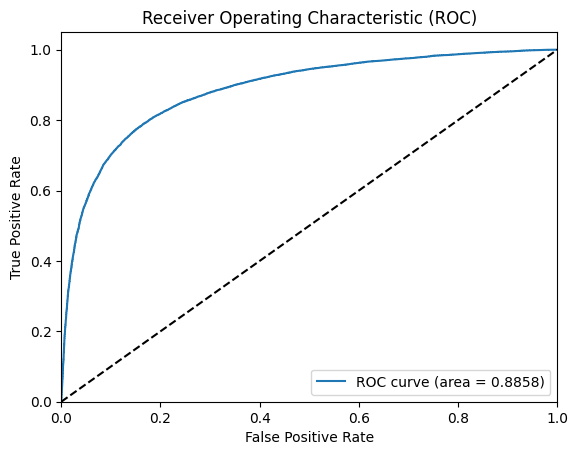

In [ ]:
# moco swin 정의
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
from tqdm import tqdm

#########################################
# 기존 Swin Transformer (Supervised) 코드
#########################################
def window_partition(x, window_size):
    """
    x: (B, H, W, C)
    window_size: int
    return: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous()  # (B, num_win_h, num_win_w, window_size, window_size, C)
    windows = windows.view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """
    windows: (num_windows*B, window_size, window_size, C)
    return: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(B, H, W, -1)
    return x

###############################
# Patch Embedding
###############################
class PatchEmbed(nn.Module):
    """
    72x72 이미지 -> patch_size=2 -> 36x36 패치 수 -> 임베딩 dim=64
    """
    def __init__(self, img_size=72, patch_size=2, in_chans=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
    def forward(self, x):
        # x: (B, 3, 72, 72)
        x = self.proj(x)  # (B, 64, 36, 36)
        x = x.flatten(2).transpose(1,2)  # (B, 36*36, 64)
        return x

###############################
# Window Attention
###############################
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads

        # QKV
        self.qkv = nn.Linear(dim, dim*3, bias=True)
        self.proj = nn.Linear(dim, dim)

        # 상대 위치 편향 테이블
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1)*(2*window_size-1), num_heads)
        )

        # 상대 위치 인덱스 계산
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1,2,0).contiguous()
        relative_coords[:,:,0] += window_size - 1
        relative_coords[:,:,1] += window_size - 1
        relative_coords[:,:,0] *= 2*window_size - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)

        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)
    def forward(self, x, mask=None):
        """
        x: (num_windows*B, window_size*window_size, C)
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C//self.num_heads)
        qkv = qkv.permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B_, num_heads, N, head_dim)

        # 어텐션 스코어 계산
        attn = (q @ k.transpose(-2, -1)) / (q.shape[-1]**0.5)

        # 상대 위치 편향 적용
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size*self.window_size, self.window_size*self.window_size, -1)
        relative_position_bias = relative_position_bias.permute(2,0,1).unsqueeze(0)
        attn = attn + relative_position_bias

        # 마스크 적용 (shifted 윈도우용)
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_//nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = F.softmax(attn, dim=-1)
        else:
            attn = F.softmax(attn, dim=-1)

        out = (attn @ v).transpose(1,2).reshape(B_, N, C)
        out = self.proj(out)
        return out

###############################
# Swin Transformer Block
###############################
class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )

        # 마스크 생성 (shift가 적용된 경우)
        if shift_size > 0:
            H, W = input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -window_size),
                        slice(-window_size, -shift_size),
                        slice(-shift_size, None))
            w_slices = (slice(0, -window_size),
                        slice(-window_size, -shift_size),
                        slice(-shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, window_size)
            mask_windows = mask_windows.view(-1, window_size*window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)
    def forward(self, x):
        B, L, C = x.shape
        H, W = self.input_resolution
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # Shift 적용
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1,2))
        else:
            shifted_x = x

        # 윈도우 분할 후 어텐션
        x_windows = window_partition(shifted_x, self.window_size)  # (num_windows*B, window_size, window_size, C)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows, mask=self.attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)

        # 윈도우 복원
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        # Shift 복원 (역 shift)
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1,2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

###############################
# Patch Merging
###############################
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)
    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature size mismatch"

        x = x.view(B, H, W, C)
        # 2x2 패치 병합
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], dim=-1)  # (B, H/2, W/2, 4*C)
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        return x

###############################
# Swin Stage
###############################
class SwinTransformerStage(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size=3, mlp_ratio=4.0):
        super().__init__()
        self.blocks = nn.ModuleList()
        for i in range(depth):
            shift_size = window_size // 2 if (i % 2 == 1) else 0
            block = SwinTransformerBlock(dim, input_resolution, num_heads, window_size, shift_size, mlp_ratio)
            self.blocks.append(block)
    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return x

###############################
# 최종 Swin Transformer 모델
###############################
class CustomSwinTransformer(nn.Module):
    """
    72x72 -> PatchEmbed(36x36) -> Stage1 -> PatchMerging(18x18) -> Stage2 -> PatchMerging(9x9) -> Stage3
    """
    def __init__(self, img_size=72, patch_size=2, in_chans=3,
                 stage_blocks=[2, 2, 4], stage_dims=[64, 128, 256],
                 stage_heads=[2, 4, 8], window_size=3, num_classes=2):
        super().__init__()
        # 1) Patch Embedding
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, stage_dims[0])
        # 해상도: 72 -> 36
        resolution = (img_size // patch_size, img_size // patch_size)  # (36, 36)

        # 2) Stage1
        self.stage1 = SwinTransformerStage(stage_dims[0], resolution, stage_blocks[0], stage_heads[0], window_size)

        # 3) Patch Merging -> 해상도 36 -> 18
        self.patch_merging1 = PatchMerging(resolution, stage_dims[0])
        resolution_stage2 = (resolution[0] // 2, resolution[1] // 2)  # (18, 18)

        # 4) Stage2
        self.stage2 = SwinTransformerStage(stage_dims[1], resolution_stage2, stage_blocks[1], stage_heads[1], window_size)

        # 5) Patch Merging -> 해상도 18 -> 9
        self.patch_merging2 = PatchMerging(resolution_stage2, stage_dims[1])
        resolution_stage3 = (resolution_stage2[0] // 2, resolution_stage2[1] // 2)  # (9, 9)

        # 6) Stage3
        self.stage3 = SwinTransformerStage(stage_dims[2], resolution_stage3, stage_blocks[2], stage_heads[2], window_size)

        # 7) LayerNorm & Head (classification head는 사전학습 시 사용하지 않습니다)
        self.norm = nn.LayerNorm(stage_dims[2])
        self.head = nn.Linear(stage_dims[2], num_classes)
    def forward_features(self, x):
        x = self.patch_embed(x)                   # (B, 36*36, 64)
        x = self.stage1(x)                        # (B, 1296, 64)
        x = self.patch_merging1(x)                # (B, 324, 128)
        x = self.stage2(x)                        # (B, 324, 128)
        x = self.patch_merging2(x)                # (B, 81, 256)
        x = self.stage3(x)                        # (B, 81, 256)
        x = self.norm(x)                          # (B, 81, 256)
        x = x.mean(dim=1)                         # Global Average Pooling -> (B, 256)
        return x
    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

print("===== Swin Transformer 모델 정의 완료 =====")

# moco swin 정의
#########################################
# Projection Head for MoCo
#########################################
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

#########################################
# MoCoSwin: MoCo 스타일 wrapper for Swin encoder
#########################################
class MoCoSwin(nn.Module):
    def __init__(self, base_encoder, feature_dim=128, m=0.99, T=0.07, queue_size=1024):
        """
        base_encoder: CustomSwinTransformer (classification head는 사용하지 않고 forward_features를 이용)
        feature_dim: Projection head 출력 차원
        m: 모멘텀 계수
        T: temperature
        """
        super().__init__()
        self.m = m
        self.T = T
        self.queue_size = queue_size

        # query, key encoder (dummy classification head 사용)
        self.encoder_q = base_encoder(num_classes=2)
        self.encoder_k = base_encoder(num_classes=2)
        self.proj_q = ProjectionHead(in_dim=256, hidden_dim=256, out_dim=feature_dim)
        self.proj_k = ProjectionHead(in_dim=256, hidden_dim=256, out_dim=feature_dim)

        # 초기화: key encoder와 proj_k를 query와 동일하게 초기화하고, grad 계산 없이 업데이트
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False
        for param_q, param_k in zip(self.proj_q.parameters(), self.proj_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

        # Negative queue: (feature_dim, queue_size)
        self.register_buffer("queue", torch.randn(feature_dim, queue_size))
        self.queue = F.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))
    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)
        for param_q, param_k in zip(self.proj_q.parameters(), self.proj_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)
    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + batch_size <= self.queue_size:
            self.queue[:, ptr:ptr+batch_size] = keys.T
            ptr = (ptr + batch_size) % self.queue_size
        else:
            first_part = self.queue_size - ptr
            self.queue[:, ptr:] = keys[:first_part].T
            second_part = batch_size - first_part
            self.queue[:, :second_part] = keys[first_part:].T
            ptr = second_part
        self.queue_ptr[0] = ptr
    def forward(self, im_q, im_k):
        # Query branch
        q_feat = self.encoder_q.forward_features(im_q)  # (B, 256)
        q = self.proj_q(q_feat)  # (B, feature_dim)
        q = F.normalize(q, dim=1)
        # Key branch (모멘텀 업데이트 후)
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k_feat = self.encoder_k.forward_features(im_k)  # (B, 256)
            k = self.proj_k(k_feat)
            k = F.normalize(k, dim=1)
        # positive logits
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)
        # negative logits
        l_neg = torch.mm(q, self.queue.clone().detach())
        logits = torch.cat([l_pos, l_neg], dim=1)
        logits /= self.T
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(logits.device)
        self._dequeue_and_enqueue(k)
        return logits, labels

print("모코(MoCo) 모델 및 유틸리티 정의 완료.")

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import time  # 에폭 시간 측정을 위한 모듈

# === CustomSwinTransformer, MyDataset 등의 클래스는 이미 정의되어 있다고 가정 ===
# 아래는 MyDataset 클래스 예시입니다.
class MyDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None, max_samples=200000):
        self.img_dir = img_dir
        df = pd.read_csv(csv_file)
        df = df.iloc[:max_samples].reset_index(drop=True)
        self.labels_df = df
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# Fine-tuning을 위한 CustomSwinTransformer 인스턴스 생성 (예: num_classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ft = CustomSwinTransformer(
    img_size=72,
    patch_size=2,
    in_chans=3,
    stage_blocks=[2, 2, 4],
    stage_dims=[64, 128, 256],
    stage_heads=[2, 4, 8],
    window_size=3,
    num_classes=2  # 파인튜닝 대상 task의 클래스 수로 설정
).to(device)

# 사전학습된 MoCo 모델 checkpoint 불러오기
checkpoint_path = "moco_pretrained_swin_additional72_4.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# checkpoint에서 encoder_q의 가중치만 추출하여 fine-tuning 모델에 로드합니다.
pretrained_dict = {}
for k, v in checkpoint.items():
    if k.startswith("encoder_q."):
        # "encoder_q." prefix를 제거하여, 모델의 state dict 키와 맞춥니다.
        new_key = k[len("encoder_q."):]
        pretrained_dict[new_key] = v

# 모델의 state dict에 사전학습 가중치를 업데이트 (분류 head는 새로 초기화됨)
model_ft.load_state_dict(pretrained_dict, strict=False)
print("사전학습된 가중치가 성공적으로 로드되었습니다.")

# 데이터셋 준비 (앞 200,000개 샘플 중 사용)
img_dir = r"C:\Users\rkatk\Desktop\학부연구생\dataset_1000k(72x72)"
csv_file = os.path.join(img_dir, "labels.csv")
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(72, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
dataset = MyDataset(img_dir, csv_file, transform=train_transform, max_samples=200000)

# train/val 분할 (80/20 랜덤 분할)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset = Subset(dataset, range(0, train_size))
val_dataset = Subset(dataset, range(train_size, len(dataset)))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

# 손실함수, 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=1e-4)

# 모델 파라미터 수 출력
total_params = sum(p.numel() for p in model_ft.parameters())
print(f"총 모델 파라미터 수: {total_params}")

# 파인튜닝 학습 루프 (에폭 당 소요 시간 출력)
num_epochs = 20
best_val_acc = 0.0  # 최고 검증 정확도를 저장하기 위한 변수
best_model_path = "finetuned_swin72_best.pth"

for epoch in range(num_epochs):
    epoch_start = time.time()  # 에폭 시작 시간 기록
    model_ft.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_ft(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model_ft.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_ft(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    epoch_time = time.time() - epoch_start
    # mm:ss 형식으로 소요 시간 출력
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | Time: {time.strftime('%M:%S', time.gmtime(epoch_time))}")

    # 최고 검증 정확도일 때 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_ft.state_dict(), best_model_path)
        print(f"새로운 최고 검증 정확도 {best_val_acc:.4f} 달성! 모델 저장: {best_model_path}")

print("파인튜닝 완료!")
print("최고 검증 정확도를 가진 모델이 저장되었습니다:", best_model_path)


import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# 저장된 최고 성능 모델을 불러옵니다.
model_ft.load_state_dict(torch.load(best_model_path, map_location=device))
model_ft.eval()

all_labels = []
all_probs = []

# 검증 데이터셋에 대해 모델의 예측 확률 및 실제 라벨 수집
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_ft(images)
        # 두 클래스에 대한 softmax 확률 계산 (여기서는 양성 클래스, 즉 클래스 1의 확률 사용)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ROC 곡선 및 AUC 계산
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
# 또는 roc_auc = roc_auc_score(all_labels, all_probs)

print("Validation ROC AUC: {:.4f}".format(roc_auc))

# ROC 곡선 시각화
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = {:.4f})".format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()